In [75]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor, XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df = pd.read_csv("auction_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (18000, 12)


,auction_id,starting_price,current_bid,bidders,total_bids,avg_increment,bid_velocity,auction_duration,time_remaining,final_price,winner_id,will_win
0,1,811,2338,9,42,82,8.0,58,70,2350,17,1
1,2,1906,3024,20,104,193,8.0,180,3,6921,5,0
2,3,1490,4820,2,36,151,8.0,192,51,4622,16,1
3,4,1237,3725,9,44,125,8.0,115,41,3680,1,1
4,5,396,1099,11,57,40,8.0,110,76,1383,8,1


In [78]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['auction_id', 'starting_price', 'current_bid', 'bidders', 'total_bids',
       'avg_increment', 'bid_velocity', 'auction_duration', 'time_remaining',
       'final_price', 'winner_id', 'will_win'],
      dtype='object')


In [79]:
df = df.dropna()

print("After cleaning:", df.shape)

After cleaning: (18000, 12)


In [80]:
# Regression target
y_reg = df["final_price"]

# Classification target (balanced)
df["auction_winner"] = (df["final_price"] > df["final_price"].median()).astype(int)

y_cls = df["auction_winner"]

print("Class distribution:")
print(y_cls.value_counts())

Class distribution:
auction_winner
0    9002
1    8998
Name: count, dtype: int64


In [81]:
X = df.drop(["final_price", "auction_winner"], axis=1, errors="ignore")

print("Feature shape:", X.shape)

Feature shape: (18000, 11)


In [82]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [83]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_scaled,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

In [84]:
reg_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

reg_model.fit(X_train, y_train_reg)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [85]:
y_pred_reg = reg_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 209.0324062795049
MAE: 145.73239135742188
R2 Score: 0.9882117509841919


In [86]:
cls_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

cls_model.fit(X_train_cls, y_train_cls)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [87]:
y_pred_cls = cls_model.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls))

Accuracy: 0.9725

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1800
           1       0.97      0.97      0.97      1800

    accuracy                           0.97      3600
   macro avg       0.97      0.97      0.97      3600
weighted avg       0.97      0.97      0.97      3600



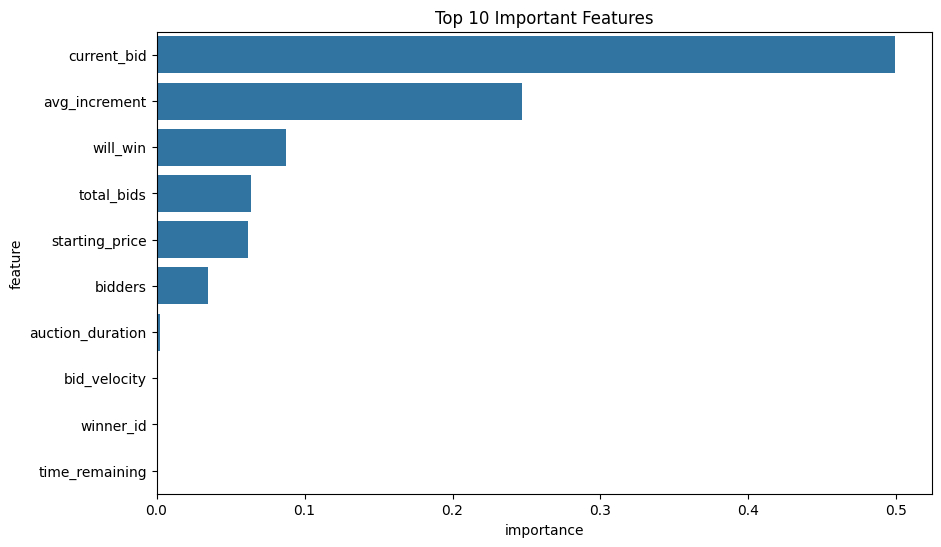

In [88]:
importance = reg_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [89]:
import joblib

# Save regression model (final price prediction)
joblib.dump(reg_model, "final_price_model.pkl")

# Save classification model (win probability)
joblib.dump(cls_model, "win_probability_model.pkl")

print("Models saved successfully!")

Models saved successfully!


In [90]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(cls_model, X, y_cls, cv=5)

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.97472222 0.97194444 0.97333333 0.9775     0.97055556]
Average accuracy: 0.9736111111111111


In [91]:
train_acc = cls_model.score(X_train, y_train)
test_acc = cls_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

NameError: name 'y_train' is not defined

In [92]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = reg_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
r2 = r2_score(y_test_reg, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 209.0324062795049
R2 Score: 0.9882117509841919


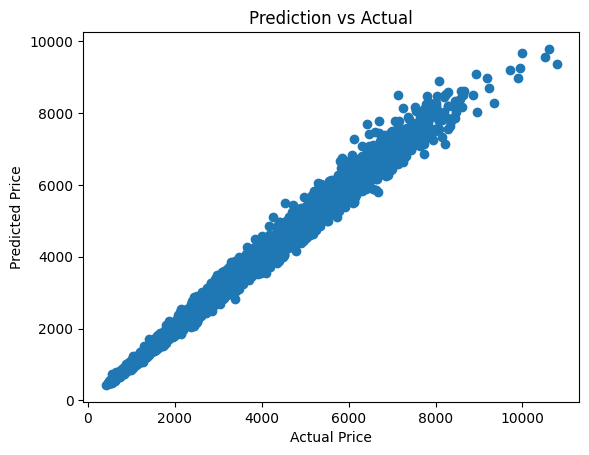

In [93]:
import matplotlib.pyplot as plt

plt.scatter(y_test_reg, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Prediction vs Actual")
plt.show()

In [94]:
train_acc = cls_model.score(X_train_cls, y_train_cls)
test_acc = cls_model.score(X_test_cls, y_test_cls)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9938888888888889
Test Accuracy: 0.9725


In [95]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = cls_model.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred))

Accuracy: 0.9725

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1800
           1       0.97      0.97      0.97      1800

    accuracy                           0.97      3600
   macro avg       0.97      0.97      0.97      3600
weighted avg       0.97      0.97      0.97      3600

